# Complex Numbers — Lecture 5
## Three Forms of a Complex Number · Polar (Trigonometric) Form · Euler's Formula · Exponential Form · $i^i$

**Source:** [Complex Numbers 05 | Polar & Euler Form of a Complex Number | Class 11 | JEE](https://youtu.be/CYnXd-L8KI8), Physics Wallah (Class 11), about 45 min

**Prerequisite:** Lecture 2 (modulus $|z|$), Lecture 4 (argument $\arg z$, principal value in $(-\pi, \pi]$).

### What this lecture covers
1. The **three ways** to write a complex number: algebraic, polar (trigonometric), exponential (Euler)
2. **Deriving the polar form** $z = r(\cos\theta + i\sin\theta)$ from the Argand diagram, and why it's called "polar"
3. The shorthand $\operatorname{cis}\theta = \cos\theta + i\sin\theta$
4. Converting to polar form: $-1 - \sqrt3\,i$ and $i$
5. **Euler's formula** $e^{i\theta} = \cos\theta + i\sin\theta$, with the lecturer's proof using integration (for interest, not in the syllabus)
6. **Exponential form** $z = re^{i\theta}$, and $2 + 2i$ written in all three forms
7. **Question:** is $i^i$ real, purely imaginary, both or neither?
8. Answers to the Lecture 4 homework

> The lecturer's opening: if complex numbers had an ID card, *"mother's name: algebra."* And: *"the whole chapter lives inside these three forms. Command them, and you command complex numbers."*

Sections marked *(extra)* go beyond what was said in the lecture.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
from matplotlib import animation
from IPython.display import HTML

# Same look as Lectures 1–4
BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": INK2, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
    "animation.embed_limit": 30,
})
rng = np.random.default_rng(5)

def argand(ax, lim=2.5, ticks=1):
    # Draw the complex plane: real axis horizontal, imaginary axis vertical
    ax.axhline(0, color=INK2, lw=1); ax.axvline(0, color=INK2, lw=1)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
    t = np.arange(ticks, lim, ticks); t = np.r_[-t[::-1], 0, t]
    ax.set_xticks(t)
    ax.set_yticks(t, ["0" if v == 0 else "i" if v == 1 else "−i" if v == -1 else f"{v:g}i".replace("-", "−") for v in t])
    ax.set_xlabel("Re"); ax.set_ylabel("Im")

def arrow(ax, z0, z1, color, lw=2):
    z0, z1 = complex(z0), complex(z1)
    ax.annotate("", (z1.real, z1.imag), (z0.real, z0.imag),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, mutation_scale=14, shrinkA=0, shrinkB=0))

def angle_arc(ax, theta, r=0.5, color=ORANGE, lw=2, start=0.0):
    # Arc from `start` to `theta` with an arrowhead showing the direction
    t = np.linspace(start, theta, 80)
    ax.plot(r*np.cos(t), r*np.sin(t), color=color, lw=lw)
    ax.annotate("", (r*np.cos(t[-1]), r*np.sin(t[-1])), (r*np.cos(t[-6]), r*np.sin(t[-6])),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, mutation_scale=12))

def pi_str(x):
    # Pretty-print a multiple of π/12 like "5π/6" or "−π/4"
    from fractions import Fraction
    f = Fraction(x/np.pi).limit_denominator(12)
    if f == 0: return "0"
    s = "−" if f < 0 else ""; f = abs(f)
    num = "" if f.numerator == 1 else str(f.numerator)
    return f"{s}{num}π" + ("" if f.denominator == 1 else f"/{f.denominator}")

def polar(z):
    # (r, θ) with θ the principal argument
    return abs(z), np.angle(z)
print("ready")

ready


---
## 1. Three Ways to Write a Complex Number

| Form | Also called | Looks like | Built from |
|---|---|---|---|
| **Algebraic** | standard / Cartesian | $z = x + iy$ | real part, imaginary part |
| **Polar** | **trigonometric** | $z = r(\cos\theta + i\sin\theta)$ | modulus $r$, argument $\theta$ |
| **Exponential** | **Euler** form | $z = re^{i\theta}$ | modulus $r$, argument $\theta$ |

All three describe the **same number**. Only its "look" changes. So far we have only used the algebraic form. This lecture builds the other two.

---
## 2. Polar (Trigonometric) Form

Plot $z = x + iy$ at the point $P(x, y)$. Let
$$r = |z| = OP \quad\text{(distance from the origin)}, \qquad \theta = \arg z \quad\text{(angle from the positive real axis)}$$

Drop a perpendicular from $P$ to the real axis. In the right triangle the horizontal side is $x$, the vertical side is $y$ and the hypotenuse is $r$:
$$\cos\theta = \frac{x}{r} \;\Rightarrow\; x = r\cos\theta, \qquad \sin\theta = \frac{y}{r} \;\Rightarrow\; y = r\sin\theta$$

Substitute into $z = x + iy$:
$$z = r\cos\theta + i\,r\sin\theta$$
$$\boxed{z = r(\cos\theta + i\sin\theta), \qquad r = |z|,\; \theta = \arg z}$$

**Why "trigonometric"?** It is written with $\cos$ and $\sin$.

**Why "polar"?** In coordinate geometry, $(x, y)$ are **Cartesian coordinates**. A point can also be located by $(r, \theta)$, its distance from the origin and its direction. These are its **polar coordinates**. Every point of the plane has a unique pair $(r, \theta)$, with $\theta$ the principal value, just as it has a unique $(x, y)$. Writing $z$ using $r$ and $\theta$ gives the polar form.

> **To write any $z$ in polar form you need exactly two things: its modulus and its argument.**

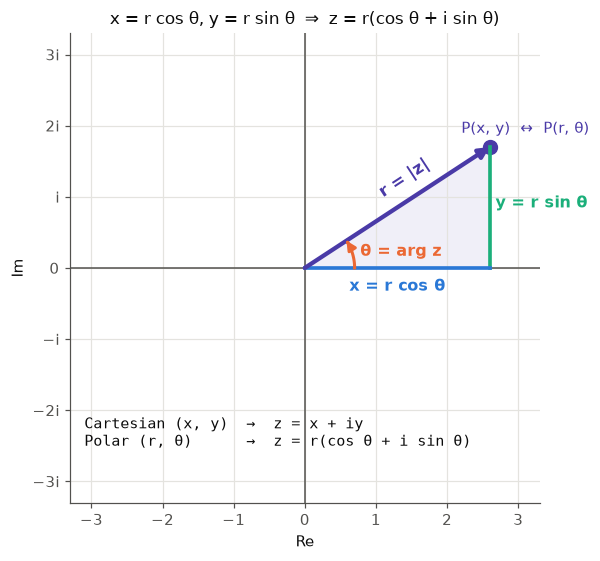

In [2]:
z = 2.6 + 1.7j; r, th = polar(z)
fig, ax = plt.subplots(figsize=(6.6, 5.2)); argand(ax, lim=3.3)
ax.fill([0, z.real, z.real], [0, 0, z.imag], color=VIOLET, alpha=0.08)
arrow(ax, 0, z, VIOLET, 2.8); ax.plot(z.real, z.imag, "o", color=VIOLET, ms=9)
ax.plot([z.real, z.real], [0, z.imag], color=AQUA, lw=2.4); ax.plot([0, z.real], [0, 0], color=BLUE, lw=2.4)
ax.text(z.real/2, -0.32, "x = r cos θ", color=BLUE, ha="center", fontsize=10.5, weight="bold")
ax.text(z.real + 0.08, z.imag/2, "y = r sin θ", color=AQUA, fontsize=10.5, weight="bold")
ax.text(1.0, 1.0, "r = |z|", color=VIOLET, fontsize=11, weight="bold", rotation=np.degrees(th))
angle_arc(ax, th, r=0.7)
ax.text(0.78, 0.17, "θ = arg z", color=ORANGE, fontsize=10.5, weight="bold")
ax.text(z.real - 0.4, z.imag + 0.2, "P(x, y)  ↔  P(r, θ)", color=VIOLET, fontsize=10)
ax.text(-3.1, -2.5, "Cartesian (x, y)  →  z = x + iy\nPolar (r, θ)      →  z = r(cos θ + i sin θ)",
        fontsize=9.5, family="monospace")
ax.set_title("x = r cos θ, y = r sin θ  ⇒  z = r(cos θ + i sin θ)", fontsize=11)
plt.tight_layout(); plt.show()

### Shorthand: $\operatorname{cis}\theta$
$\cos\theta + i\sin\theta$ appears so often that some mathematicians got tired of writing it and took **c**os, **i**, **s**in:
$$\operatorname{cis}\theta = \cos\theta + i\sin\theta, \qquad\text{so}\qquad z = r\operatorname{cis}\theta$$
$\operatorname{cis}\theta$ is **not** a new trigonometric ratio. It's just a short way of writing $\cos\theta + i\sin\theta$.

### Example 1: $z = -1 - \sqrt3\,i$
1. **Plot it.** Both parts are negative, so it's in **quadrant III**.
2. **Modulus:** $r = \sqrt{(-1)^2 + (-\sqrt3)^2} = \sqrt{4} = 2$.
3. **Argument:** acute angle $\tan\alpha = \frac{\sqrt3}{1}$, so $\alpha = \frac{\pi}{3}$. In quadrant III, measure clockwise: $\theta = -\left(\pi - \frac{\pi}{3}\right) = -\frac{2\pi}{3}$.
$$\boxed{-1 - \sqrt3\,i = 2\left[\cos\left(-\tfrac{2\pi}{3}\right) + i\sin\left(-\tfrac{2\pi}{3}\right)\right]}$$

### Example 2: $z = i$
$r = 1$ and $\theta = \frac{\pi}{2}$ (positive imaginary axis), so
$$\boxed{i = 1\left(\cos\tfrac{\pi}{2} + i\sin\tfrac{\pi}{2}\right)}$$
Check: $\cos\frac{\pi}{2} = 0$, $\sin\frac{\pi}{2} = 1$, which gives back $0 + 1\cdot i = i$. ✓

In [3]:
for name, z in [("−1 − √3 i", -1 - np.sqrt(3)*1j), ("i", 1j), ("2 + 2i", 2 + 2j)]:
    r, th = polar(z)
    back = r*(np.cos(th) + 1j*np.sin(th))
    print(f"{name:>9}:  r = {r:.4f},  θ = {pi_str(th):>6}   →  r(cos θ + i sin θ) = {back.real:+.4f} {back.imag:+.4f}i   matches: {np.isclose(back, z)}")

−1 − √3 i:  r = 2.0000,  θ =  −2π/3   →  r(cos θ + i sin θ) = -1.0000 -1.7321i   matches: True
        i:  r = 1.0000,  θ =    π/2   →  r(cos θ + i sin θ) = +0.0000 +1.0000i   matches: True
   2 + 2i:  r = 2.8284,  θ =    π/4   →  r(cos θ + i sin θ) = +2.0000 +2.0000i   matches: True


---
## 3. Euler's Formula

Everything was going fine with the algebraic and polar forms. Then **Euler** proved something remarkable about $\cos\theta + i\sin\theta$:
$$\boxed{e^{i\theta} = \cos\theta + i\sin\theta}$$
A **trigonometric** expression turns out to be an **exponential**. This is known as **Euler's formula** (or Euler's property).

> *Pronunciation aside from the lecture:* the lecturer says "Euler", the way the mathematician's mother said it, so he keeps calling it that.

### The lecturer's proof (uses integration, for interest only, not in the syllabus)
Let
$$t = \cos\theta + i\sin\theta$$
Differentiate with respect to $\theta$:
$$\frac{dt}{d\theta} = -\sin\theta + i\cos\theta = i(\cos\theta + i\sin\theta) = i\,t$$
(Check the middle step: $i\cos\theta + i^2\sin\theta = i\cos\theta - \sin\theta$. ✓)

Separate and integrate both sides:
$$\int\frac{dt}{t} = \int i\,d\theta \;\Longrightarrow\; \ln t = i\theta + C$$
At $\theta = 0$: $t = \cos0 + i\sin0 = 1$, so $\ln1 = 0 = C$. Therefore
$$\ln t = i\theta \;\Longrightarrow\; t = e^{i\theta} \;\Longrightarrow\; \cos\theta + i\sin\theta = e^{i\theta} \quad\blacksquare$$

There are many other proofs. The lecturer calls this one the most satisfying. A second proof using power series follows below as an extra.

In [4]:
theta = rng.uniform(-10, 10, 100_000)
lhs, rhs = np.exp(1j*theta), np.cos(theta) + 1j*np.sin(theta)
print(f"e^(iθ) = cos θ + i sin θ  holds on {np.isclose(lhs, rhs).mean()*100:.2f}% of 100,000 random θ")
print("|e^(iθ)| = 1 for all θ?", np.allclose(np.abs(lhs), 1))
# Check the key step of the proof: dt/dθ = i t, numerically
h, th0 = 1e-6, 0.83
t = lambda a: np.cos(a) + 1j*np.sin(a)
print("dt/dθ ≈", np.round((t(th0 + h) - t(th0 - h))/(2*h), 6), "   i·t =", np.round(1j*t(th0), 6))

e^(iθ) = cos θ + i sin θ  holds on 100.00% of 100,000 random θ
|e^(iθ)| = 1 for all θ? True
dt/dθ ≈ (-0.737931+0.674876j)    i·t = (-0.737931+0.674876j)


### Animation *(extra)*: $e^{i\theta}$ walks around the unit circle
Since $|e^{i\theta}| = \sqrt{\cos^2\theta + \sin^2\theta} = 1$, the point $e^{i\theta}$ always sits on the **unit circle**, at angle $\theta$. As $\theta$ grows, it walks around anticlockwise:
- its **shadow on the real axis** is $\cos\theta$ (blue curve on the right),
- its **shadow on the imaginary axis** is $\sin\theta$ (green curve).

So Euler's formula says the same thing as "a point on the unit circle at angle $\theta$ has coordinates $(\cos\theta, \sin\theta)$", now written as a single number.

In [5]:
fig = plt.figure(figsize=(12, 4.8), dpi=72)
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.6])
ax = fig.add_subplot(gs[0]); argand(ax, lim=1.4)
ax2 = fig.add_subplot(gs[1])
c = np.linspace(0, 2*np.pi, 300); ax.plot(np.cos(c), np.sin(c), color=GRID, lw=2)
vec, = ax.plot([], [], color=VIOLET, lw=2.6); dot, = ax.plot([], [], "o", color=VIOLET, ms=9)
hx, = ax.plot([], [], color=BLUE, lw=4, alpha=0.7); hy, = ax.plot([], [], color=AQUA, lw=4, alpha=0.7)
arc, = ax.plot([], [], color=ORANGE, lw=2)
lbl = ax.text(-1.35, -1.32, "", fontsize=10, family="monospace")
ax.set_title(r"z = $e^{i\theta}$ on the unit circle", fontsize=10.5)
T = np.linspace(0, 2*np.pi, 400)
ax2.plot(T, np.cos(T), color=BLUE, lw=1, alpha=0.25); ax2.plot(T, np.sin(T), color=AQUA, lw=1, alpha=0.25)
cl, = ax2.plot([], [], color=BLUE, lw=2.5, label=r"Re $e^{i\theta}$ = cos θ"); sl, = ax2.plot([], [], color=AQUA, lw=2.5, label=r"Im $e^{i\theta}$ = sin θ")
cd, = ax2.plot([], [], "o", color=BLUE, ms=7); sd, = ax2.plot([], [], "o", color=AQUA, ms=7)
ax2.set_xticks(np.arange(5)*np.pi/2, ["0", "π/2", "π", "3π/2", "2π"]); ax2.set_xlim(0, 2*np.pi); ax2.set_ylim(-1.3, 1.5)
ax2.axhline(0, color=INK2, lw=0.8); ax2.set_xlabel("θ"); ax2.legend(frameon=False, ncol=2, loc="upper right", fontsize=9)
ax2.set_title("the two shadows trace cos θ and sin θ", fontsize=10.5)
N = 60
def update(f):
    th = 2*np.pi*f/N; z = np.exp(1j*th); k = np.searchsorted(T, th)
    vec.set_data([0, z.real], [0, z.imag]); dot.set_data([z.real], [z.imag])
    hx.set_data([0, z.real], [0, 0]); hy.set_data([z.real, z.real], [0, z.imag])
    a = np.linspace(0, th, 60); arc.set_data(0.3*np.cos(a), 0.3*np.sin(a))
    lbl.set_text(f"θ={th:4.2f}  e^iθ = {z.real:+.2f} {z.imag:+.2f}i")
    cl.set_data(T[:k + 1], np.cos(T[:k + 1])); sl.set_data(T[:k + 1], np.sin(T[:k + 1]))
    cd.set_data([th], [z.real]); sd.set_data([th], [z.imag])
    return vec, dot, hx, hy, arc, lbl, cl, sl, cd, sd
anim = animation.FuncAnimation(fig, update, frames=N, interval=100, blit=True)
plt.close(fig)
HTML(anim.to_jshtml(default_mode="loop"))

### A second proof *(extra)*: power series
Using the series $e^x = 1 + x + \frac{x^2}{2!} + \frac{x^3}{3!} + \cdots$ with $x = i\theta$, and the cycle $i, -1, -i, 1$ from Lecture 1:
$$e^{i\theta} = 1 + i\theta - \frac{\theta^2}{2!} - i\frac{\theta^3}{3!} + \frac{\theta^4}{4!} + i\frac{\theta^5}{5!} - \cdots$$
$$= \underbrace{\left(1 - \frac{\theta^2}{2!} + \frac{\theta^4}{4!} - \cdots\right)}_{\cos\theta} + i\underbrace{\left(\theta - \frac{\theta^3}{3!} + \frac{\theta^5}{5!} - \cdots\right)}_{\sin\theta}$$

Each new term is the previous one **turned by $90°$** (multiplied by $i$) and **shrunk**. Drawing the terms tip to tail for $\theta = \pi$ gives a spiral path that homes in on $-1$, which is **Euler's identity**:
$$e^{i\pi} = -1 \qquad\Longleftrightarrow\qquad e^{i\pi} + 1 = 0$$

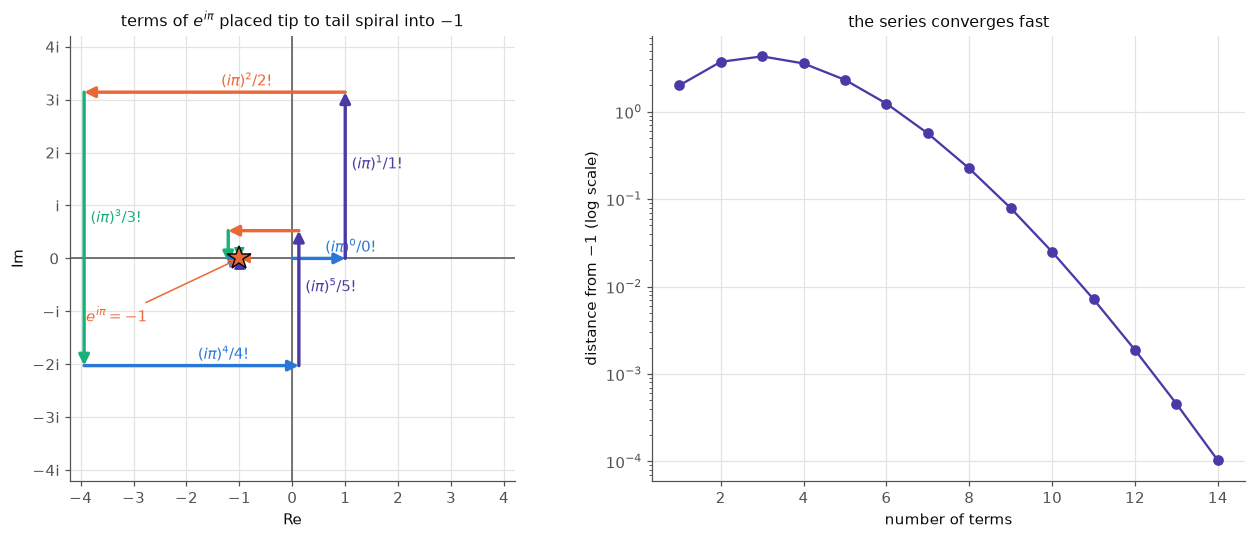

e^(iπ) + 1 = 1.2246467991473532e-16j  (zero, up to floating-point rounding)


In [6]:
theta = np.pi; n_terms = 14
terms = np.array([(1j*theta)**n/factorial(n) for n in range(n_terms)])
partial = np.r_[0, np.cumsum(terms)]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]; argand(ax, lim=4.2)
cols = [BLUE, VIOLET, ORANGE, AQUA]
for k in range(n_terms):
    arrow(ax, partial[k], partial[k + 1], cols[k % 4], 2.2 if k < 8 else 1.2)
    if k < 6:
        m = (partial[k] + partial[k + 1])/2
        ax.text(m.real + 0.12, m.imag + 0.12, rf"$(i\pi)^{k}/{k}!$", color=cols[k % 4], fontsize=9.5)
ax.plot(-1, 0, "*", color=ORANGE, ms=16, mec=INK, zorder=6); ax.annotate(r"$e^{i\pi} = -1$", (-1, 0), xytext=(-3.9, -1.2), color=ORANGE, weight="bold",
                                                                        arrowprops=dict(arrowstyle="->", color=ORANGE))
ax.set_title(r"terms of $e^{i\pi}$ placed tip to tail spiral into −1", fontsize=10.5)
ax = axes[1]
err = np.abs(partial[1:] - np.exp(1j*theta))
ax.semilogy(range(1, n_terms + 1), err, "o-", color=VIOLET)
ax.set_xlabel("number of terms"); ax.set_ylabel("distance from −1 (log scale)")
ax.set_title("the series converges fast", fontsize=10.5)
plt.tight_layout(); plt.show()
print("e^(iπ) + 1 =", np.exp(1j*np.pi) + 1, " (zero, up to floating-point rounding)")

---
## 4. Exponential (Euler) Form

Put Euler's formula into the polar form:
$$z = r(\cos\theta + i\sin\theta) = re^{i\theta}$$
"Exponential" just means something is written **in the power**, here $i\theta$.

### The three looks of one number
$$\underbrace{z = x + iy}_{\text{algebraic}} \;=\; \underbrace{r(\cos\theta + i\sin\theta)}_{\text{polar / trigonometric}} \;=\; \underbrace{re^{i\theta}}_{\text{exponential / Euler}}$$

### Example 3: $z = 2 + 2i$ in all three forms
Point $(2, 2)$, quadrant I. $r = \sqrt{4 + 4} = 2\sqrt2$. $\tan\theta = 1$, so $\theta = \frac{\pi}{4}$.
$$\boxed{2 + 2i \;=\; 2\sqrt2\left(\cos\tfrac{\pi}{4} + i\sin\tfrac{\pi}{4}\right) \;=\; 2\sqrt2\,e^{i\pi/4}}$$

**Which form should you use?** Whichever makes the question easiest. Some questions are simple in algebraic form. Many become far easier in polar or exponential form, especially anything with **products, quotients and powers**.

In [7]:
z = 2 + 2j; r, th = polar(z)
print(f"algebraic   : {z}")
print(f"polar       : {r:.4f} (cos {pi_str(th)} + i sin {pi_str(th)})  = {r*(np.cos(th) + 1j*np.sin(th)):.4f}")
print(f"exponential : {r:.4f} e^(i{pi_str(th)})                  = {r*np.exp(1j*th):.4f}")
print("r = 2√2?", np.isclose(r, 2*np.sqrt(2)))

algebraic   : (2+2j)
polar       : 2.8284 (cos π/4 + i sin π/4)  = 2.0000+2.0000j
exponential : 2.8284 e^(iπ/4)                  = 2.0000+2.0000j
r = 2√2? True


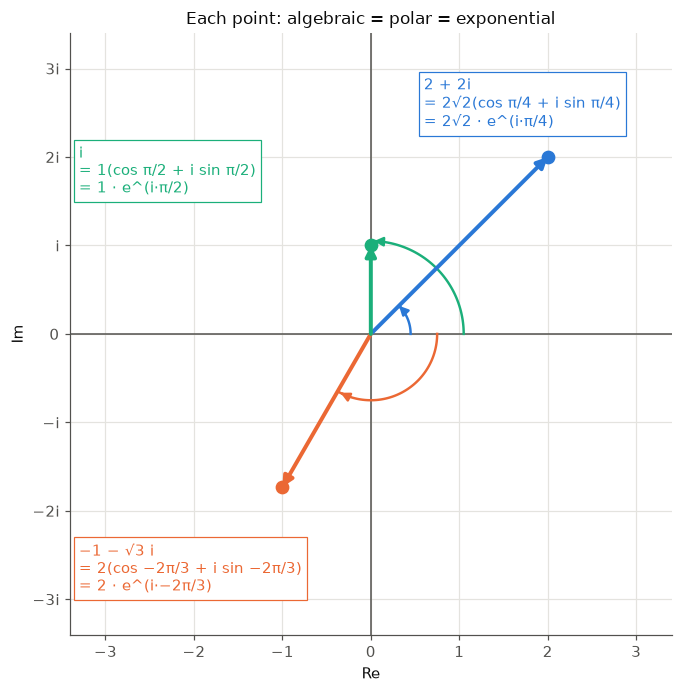

In [8]:
# One picture, three labels: the same point described three ways
examples = [("2 + 2i", 2 + 2j, BLUE), ("−1 − √3 i", -1 - np.sqrt(3)*1j, ORANGE), ("i", 1j, AQUA)]
fig, ax = plt.subplots(figsize=(7.4, 6.4)); argand(ax, lim=3.4)
for k, (name, z, col) in enumerate(examples):
    r, th = polar(z)
    arrow(ax, 0, z, col, 2.6); ax.plot(z.real, z.imag, "o", color=col, ms=8)
    angle_arc(ax, th, r=0.45 + 0.3*k, color=col, lw=1.6)
    rs = {"2 + 2i": "2√2", "−1 − √3 i": "2", "i": "1"}[name]
    txt = f"{name}\n= {rs}(cos {pi_str(th)} + i sin {pi_str(th)})\n= {rs} · e^(i·{pi_str(th)})"
    pos = {"2 + 2i": (0.6, 2.35), "−1 − √3 i": (-3.3, -2.9), "i": (-3.3, 1.6)}[name]
    ax.text(*pos, txt, color=col, fontsize=9.5, bbox=dict(fc="white", ec=col, lw=0.8, pad=3))
ax.set_title("Each point: algebraic = polar = exponential", fontsize=11)
plt.tight_layout(); plt.show()

### Why the exponential form is powerful *(extra)*
Lecture 4 promised to explain where the argument properties come from. Here it is. Multiply two numbers in exponential form using the ordinary rule for powers, $e^a e^b = e^{a+b}$:
$$z_1z_2 = r_1e^{i\theta_1}\cdot r_2e^{i\theta_2} = (r_1r_2)\,e^{i(\theta_1 + \theta_2)}$$
Read off the modulus and argument:
- $|z_1z_2| = r_1r_2 = |z_1||z_2|$ (Lectures 2–3)
- $\arg(z_1z_2) = \theta_1 + \theta_2$, plus $2k\pi$ to stay in the principal range (Lecture 4)

Likewise $\dfrac{z_1}{z_2} = \dfrac{r_1}{r_2}e^{i(\theta_1 - \theta_2)}$ and $z^n = r^ne^{in\theta}$. Products, quotients and powers become simple in this form: **lengths multiply, angles add.**

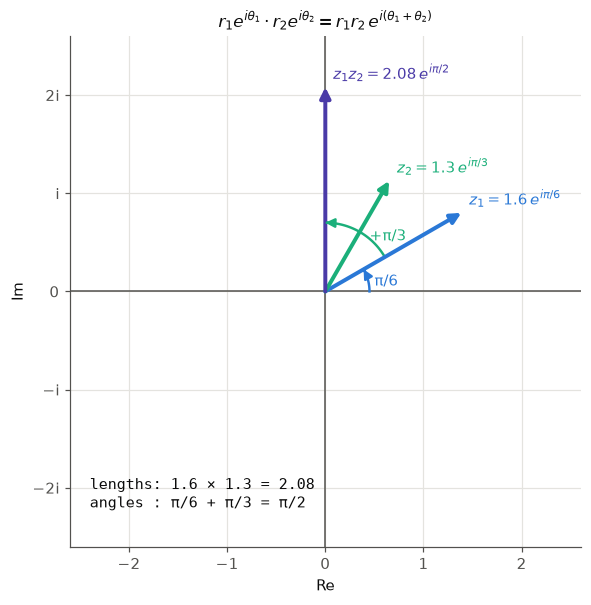

z1·z2 = 2.08j   |z1z2| = 2.08   arg = π/2


In [9]:
z1, z2 = 1.6*np.exp(1j*np.pi/6), 1.3*np.exp(1j*np.pi/3)
p = z1*z2
fig, ax = plt.subplots(figsize=(6.6, 5.6)); argand(ax, lim=2.6)
for z, col, lab in [(z1, BLUE, r"$z_1 = 1.6\,e^{i\pi/6}$"), (z2, AQUA, r"$z_2 = 1.3\,e^{i\pi/3}$"), (p, VIOLET, r"$z_1z_2 = 2.08\,e^{i\pi/2}$")]:
    arrow(ax, 0, z, col, 2.6); ax.text(z.real + 0.08, z.imag + 0.08, lab, color=col, fontsize=10, weight="bold")
angle_arc(ax, np.pi/6, r=0.45, color=BLUE, lw=1.6)
angle_arc(ax, np.pi/6 + np.pi/3, r=0.7, color=AQUA, lw=1.6, start=np.pi/6)
ax.text(0.5, 0.06, "π/6", color=BLUE); ax.text(0.45, 0.52, "+π/3", color=AQUA)
ax.text(-2.4, -2.2, "lengths: 1.6 × 1.3 = 2.08\nangles : π/6 + π/3 = π/2", fontsize=10, family="monospace")
ax.set_title(r"$r_1e^{i\theta_1}\cdot r_2e^{i\theta_2} = r_1r_2\,e^{i(\theta_1+\theta_2)}$", fontsize=11)
plt.tight_layout(); plt.show()
print("z1·z2 =", np.round(p, 6), "  |z1z2| =", round(abs(p), 6), "  arg =", pi_str(np.angle(p)))

---
## 5. Question: What Kind of Number Is $i^i$?

**Q.** Let $z = i^i$. Then $z$ is:
(a) purely real  (b) purely imaginary  (c) neither  (d) both

The lecturer asks you to attempt it before watching the solution.

**Solution.** Write the **base** $i$ in exponential form. $i$ has $r = 1$ and $\theta = \frac{\pi}{2}$:
$$i = \cos\tfrac{\pi}{2} + i\sin\tfrac{\pi}{2} = e^{i\pi/2}$$
Copy the exponent $i$ as it is, and replace only the base:
$$i^i = \left(e^{i\pi/2}\right)^i$$
Use the power rule $\left(a^m\right)^n = a^{mn}$, so the two exponents multiply:
$$i^i = e^{i\cdot i\cdot\pi/2} = e^{i^2\pi/2} = e^{-\pi/2}$$
$e^{-\pi/2}$ is an ordinary **real number**, about $0.2079$. Its imaginary part is $0$:
$$\boxed{i^i = e^{-\pi/2} \approx 0.2079 \;\Rightarrow\; \text{(a) purely real}}$$

> *"Imaginary to the power imaginary turned out real. Imagined things can become real, if you have the power of the exponential form."*

**Note *(extra)*:** using the general argument $i = e^{i(\pi/2 + 2k\pi)}$ gives a whole family of values $i^i = e^{-\pi/2 - 2k\pi}$. **Every one of them is real**, so the answer (a) doesn't depend on that choice. $e^{-\pi/2}$ is the **principal value**, the one using the principal argument and the one Python returns.

Python: 1j ** 1j = (0.20787957635076193+0j)
e^(−π/2)        = 0.20787957635076193
imaginary part  = 0.0  → purely real

other values e^(−π/2 − 2kπ):
  k = -1:  111.318
  k = +0:  0.20788
  k = +1:  0.000388203
  k = +2:  7.24947e-07


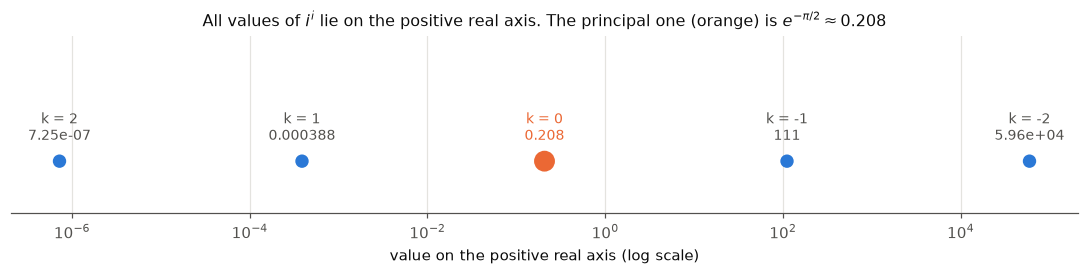

In [10]:
print("Python: 1j ** 1j =", 1j**1j)
print("e^(−π/2)        =", np.exp(-np.pi/2))
print("imaginary part  =", (1j**1j).imag, " → purely real")
print("\nother values e^(−π/2 − 2kπ):")
for k in [-1, 0, 1, 2]:
    print(f"  k = {k:+d}:  {np.exp(-np.pi/2 - 2*k*np.pi):.6g}")

fig, ax = plt.subplots(figsize=(10, 2.6))
ks = np.arange(-2, 3); vals = np.exp(-np.pi/2 - 2*ks*np.pi)
ax.scatter(vals, np.zeros_like(vals), s=[160 if k == 0 else 60 for k in ks], color=[ORANGE if k == 0 else BLUE for k in ks], zorder=5)
for k, v in zip(ks, vals):
    ax.annotate(f"k = {k}\n{v:.3g}", (v, 0), xytext=(0, 14), textcoords="offset points", ha="center", fontsize=9,
                color=ORANGE if k == 0 else INK2)
ax.set_xscale("log"); ax.set_yticks([]); ax.set_ylim(-0.5, 1.2); ax.spines["left"].set_visible(False)
ax.set_xlabel("value on the positive real axis (log scale)")
ax.set_title(r"All values of $i^i$ lie on the positive real axis. The principal one (orange) is $e^{-\pi/2}\approx 0.208$", fontsize=10.5)
plt.tight_layout(); plt.show()

---
## 6. Lecture 4 Homework: Answers

The lecturer went over the homework from last time. These match the answers in the Lecture 4 notes.

**1.** $z_1 = (1 + i)(\sqrt3 + i)$. By $\arg(z_1z_2) = \arg z_1 + \arg z_2 + 2k\pi$:
$$\arg z_1 = \frac{\pi}{4} + \frac{\pi}{6} + 2k\pi = \frac{5\pi}{12} + 2k\pi$$
$\frac{5\pi}{12}$ is already in $(-\pi, \pi]$, so $k = 0$ and $\operatorname{Arg} z_1 = \frac{5\pi}{12}$.

**2.** $z_2 = (1 - i)^3$. By $\arg(z^n) = n\arg z + 2k\pi$:
$$\arg z_2 = 3\left(-\frac{\pi}{4}\right) + 2k\pi = -\frac{3\pi}{4} + 2k\pi$$
Already in range, so $k = 0$ and $\operatorname{Arg} z_2 = -\frac{3\pi}{4}$.

**In exponential form *(extra)*:** $z_1 = \sqrt2e^{i\pi/4}\cdot2e^{i\pi/6} = 2\sqrt2\,e^{i\,5\pi/12}$ and $z_2 = \left(\sqrt2e^{-i\pi/4}\right)^3 = 2\sqrt2\,e^{-i\,3\pi/4}$. The arguments can be read straight off the exponent.

In [11]:
z1 = (1 + 1j)*(np.sqrt(3) + 1j); z2 = (1 - 1j)**3
for name, z in [("(1 + i)(√3 + i)", z1), ("(1 − i)³", z2)]:
    r, th = polar(z)
    print(f"{name:>16} = {z:.4f} = {r:.4f} e^(i·{pi_str(th)})   [2√2 = {2*np.sqrt(2):.4f}]")

 (1 + i)(√3 + i) = 0.7321+2.7321j = 2.8284 e^(i·5π/12)   [2√2 = 2.8284]
        (1 − i)³ = -2.0000-2.0000j = 2.8284 e^(i·−3π/4)   [2√2 = 2.8284]


---
## Summary

| Idea | Result |
|---|---|
| Three forms | $z = x + iy = r(\cos\theta + i\sin\theta) = re^{i\theta}$ |
| Link | $x = r\cos\theta$, $y = r\sin\theta$, $r = \lvert z\rvert = \sqrt{x^2 + y^2}$, $\theta = \arg z$ |
| Polar form needs | only the modulus $r$ and the argument $\theta$ |
| Names | polar = trigonometric, exponential = Euler. $(r, \theta)$ are polar coordinates, $(x, y)$ Cartesian |
| Shorthand | $\operatorname{cis}\theta = \cos\theta + i\sin\theta$, which is not a new trig ratio |
| Euler's formula | $e^{i\theta} = \cos\theta + i\sin\theta$. Proof by integration: $dt/d\theta = it$ |
| Special values | $i = e^{i\pi/2}$, $-1 = e^{i\pi}$, $1 = e^{i\cdot0}$, $-i = e^{-i\pi/2}$ |
| $i^i$ | $= e^{-\pi/2} \approx 0.2079$, **purely real** |
| Why bother *(extra)* | $r_1e^{i\theta_1}\cdot r_2e^{i\theta_2} = r_1r_2e^{i(\theta_1 + \theta_2)}$: lengths multiply, angles add |

---
## Practice *(extra)*
1. Write in polar and exponential form: (a) $\sqrt3 + i$, (b) $-4$, (c) $1 - i$, (d) $-2i$.
2. Convert to algebraic form: (a) $4e^{i\pi/3}$, (b) $\sqrt2\operatorname{cis}\left(-\frac{3\pi}{4}\right)$.
3. Using exponential form, find $(1 + i)^{8}$ in one line.
4. Show that $i^{-i}$ is also real, and find its principal value.

<details>
<summary>Answers (open after attempting)</summary>

1. (a) $2\left(\cos\frac{\pi}{6} + i\sin\frac{\pi}{6}\right) = 2e^{i\pi/6}$ (b) $4(\cos\pi + i\sin\pi) = 4e^{i\pi}$ (c) $\sqrt2\left(\cos\left(-\frac{\pi}{4}\right) + i\sin\left(-\frac{\pi}{4}\right)\right) = \sqrt2e^{-i\pi/4}$ (d) $2\left(\cos\left(-\frac{\pi}{2}\right) + i\sin\left(-\frac{\pi}{2}\right)\right) = 2e^{-i\pi/2}$
2. (a) $4\left(\frac12 + i\frac{\sqrt3}{2}\right) = 2 + 2\sqrt3\,i$ (b) $\sqrt2\left(-\frac{1}{\sqrt2} - \frac{i}{\sqrt2}\right) = -1 - i$
3. $(1 + i)^8 = \left(\sqrt2e^{i\pi/4}\right)^8 = 16e^{i2\pi} = 16$. This matches Lecture 1's trick, where $(1 + i)^2 = 2i$.
4. $i^{-i} = \left(e^{i\pi/2}\right)^{-i} = e^{-i^2\pi/2} = e^{\pi/2} \approx 4.810$.
</details>

In [12]:
# Checks for the practice set
for name, z in [("√3 + i", np.sqrt(3) + 1j), ("−4", -4 + 0j), ("1 − i", 1 - 1j), ("−2i", -2j)]:
    r, th = polar(z); print(f"1  {name:>7}: r = {r:.4f}, θ = {pi_str(th)}")
print("2a", np.round(4*np.exp(1j*np.pi/3), 6), "  2√3 =", round(2*np.sqrt(3), 6))
print("2b", np.round(np.sqrt(2)*(np.cos(-3*np.pi/4) + 1j*np.sin(-3*np.pi/4)), 6))
print("3 ", np.round((1 + 1j)**8, 6))
print("4 ", 1j**(-1j), " e^(π/2) =", np.exp(np.pi/2))

1   √3 + i: r = 2.0000, θ = π/6
1       −4: r = 4.0000, θ = π
1    1 − i: r = 1.4142, θ = −π/4
1      −2i: r = 2.0000, θ = −π/2
2a (2+3.464102j)   2√3 = 3.464102
2b (-1-1j)
3  (16+0j)
4  (4.810477380965351-0j)  e^(π/2) = 4.810477380965351
